# 📚 LOGISTIC REGRESSION: The Complete Learning Guide
## From Binary Classification to Multiclass Learning with Real-World Examples

**Author's Note:** This is a comprehensive, interactive guide for learning classification with Logistic Regression. No scary math—just clear explanations with working code and beautiful visualizations.

---

## 📖 TABLE OF CONTENTS

### **PART 1: FOUNDATIONS** 🏗️
1. [What is Classification?](#introduction)
2. [The Sigmoid Function](#sigmoid)
3. [Probability & Decision Boundaries](#decision-boundaries)

### **PART 2: REAL-WORLD EXAMPLES** 🌍
4. [Email Spam Detection](#spam-detection)
5. [Medical Diagnosis (Diabetes Prediction)](#diabetes)
6. [Credit Approval System](#credit)

### **PART 3: ADVANCED TOPICS** 🚀
7. [Multiclass Classification](#multiclass)
8. [Feature Importance & Coefficients](#feature-importance)
9. [Evaluation Metrics](#metrics)
10. [Handling Class Imbalance](#imbalance)
11. [Hyperparameter Tuning](#hyperparameters)

### **PART 4: COMPARISON & BEST PRACTICES** 🎯
12. [Logistic Regression vs Other Classifiers](#comparison)
13. [When to Use Logistic Regression](#when-to-use)
14. [Quick Reference Guide](#quick-ref)
15. [Mastery Checklist](#checklist)

---

# PART 1: FOUNDATIONS 🏗️

## <a id="introduction"></a>1️⃣ WHAT IS CLASSIFICATION?

### The Simple Version
Classification is about **predicting categories** instead of numbers.

**Examples:**
- 📧 Email: Spam or Not Spam? (2 categories)
- 🏥 Medical: Sick or Healthy? (2 categories)
- 🎬 Movie Rating: Bad, OK, Good, Excellent? (4 categories)
- 🐱 Animal: Cat, Dog, Bird, Fish? (4 categories)

### Linear Regression vs Classification

| Aspect | Linear Regression | Classification |
|--------|-------------------|----------------|
| **Output** | Continuous number | Category/Class |
| **Example** | Predict price: $50,000 | Predict: Spam or Not |
| **Best For** | Relationships | Categories |
| **Output Range** | -∞ to +∞ | 0 to 1 (probability) |

### The Logistic Regression Trick
Instead of predicting 0 or 1 directly, we predict the **probability** of being 1:
- Probability > 0.5 → Predict class 1 (Yes, Spam, Sick, etc.)
- Probability < 0.5 → Predict class 0 (No, Not Spam, Healthy, etc.)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
from sklearn.datasets import make_classification, load_iris
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("✅ All libraries imported successfully!")
print("="*70)

✅ All libraries imported successfully!


## <a id="sigmoid"></a>2️⃣ THE SIGMOID FUNCTION: The Magic Formula

### The Formula
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:
- **z** = Your linear equation (like β₀ + β₁·x from linear regression)
- **e** = Euler's number (≈ 2.71828)
- **σ(z)** = Probability (always between 0 and 1)

### Why This Function?
1. **Always returns 0 to 1** - Perfect for probabilities!
2. **S-shaped curve** - Smooth transition from 0 to 1
3. **Clear threshold at 0.5** - Easy decision boundary

### Key Properties
- When z = 0: σ(0) = 0.5 (exactly in the middle)
- When z → +∞: σ(z) → 1 (almost certain class 1)
- When z → -∞: σ(z) → 0 (almost certain class 0)


📊 THE SIGMOID FUNCTION


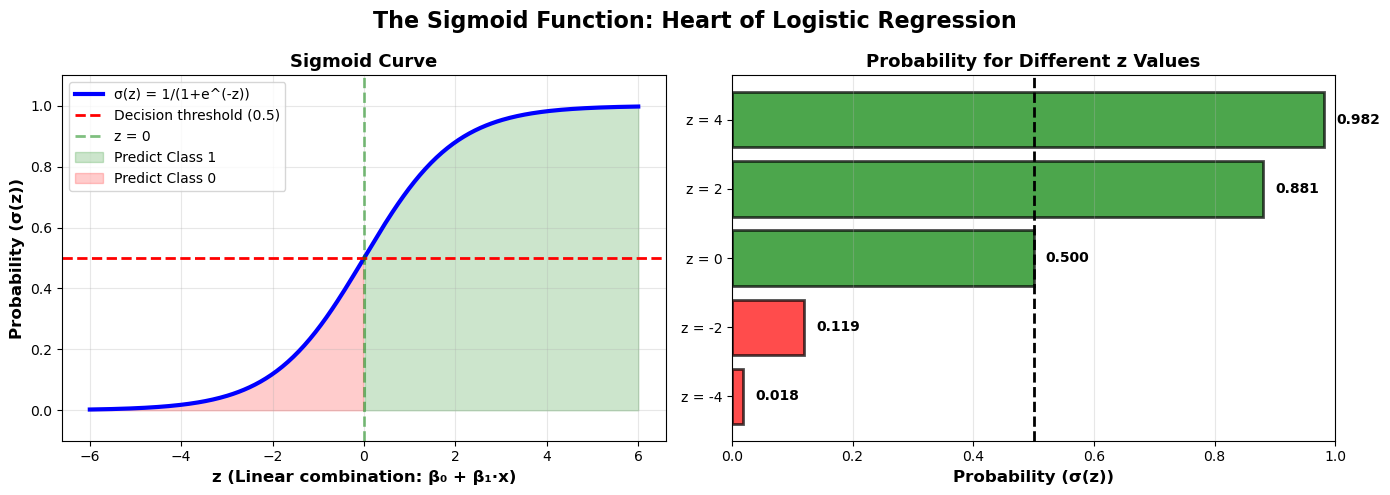


🔍 KEY OBSERVATIONS:
  • When z = 0: σ(z) = 0.500 (50% probability - exactly on the fence)
  • When z = 2: σ(z) = 0.881 (88% probability - likely class 1)
  • When z = -2: σ(z) = 0.119 (12% probability - likely class 0)
  • When z = 4: σ(z) = 0.982 (98% probability - almost certainly class 1)



In [24]:
# VISUALIZE THE SIGMOID FUNCTION
print("\n" + "="*70)
print("📊 THE SIGMOID FUNCTION")
print("="*70)

# Create z values
z = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-z))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('The Sigmoid Function: Heart of Logistic Regression', fontsize=16, fontweight='bold')

# Left plot: Sigmoid curve
ax1.plot(z, sigmoid, 'b-', linewidth=3, label='σ(z) = 1/(1+e^(-z))')
ax1.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Decision threshold (0.5)')
ax1.axvline(x=0, color='g', linestyle='--', linewidth=2, alpha=0.5, label='z = 0')
ax1.fill_between(z, 0, sigmoid, where=(sigmoid >= 0.5), alpha=0.2, color='green', label='Predict Class 1')
ax1.fill_between(z, 0, sigmoid, where=(sigmoid < 0.5), alpha=0.2, color='red', label='Predict Class 0')
ax1.set_xlabel('z (Linear combination: β₀ + β₁·x)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability (σ(z))', fontsize=12, fontweight='bold')
ax1.set_title('Sigmoid Curve', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim(-0.1, 1.1)

# Right plot: Interpretation
z_examples = [-4, -2, 0, 2, 4]
probs = [1 / (1 + np.exp(-z)) for z in z_examples]
colors = ['red' if p < 0.5 else 'green' for p in probs]

ax2.barh(range(len(z_examples)), probs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_yticks(range(len(z_examples)))
ax2.set_yticklabels([f'z = {z}' for z in z_examples])
ax2.set_xlabel('Probability (σ(z))', fontsize=12, fontweight='bold')
ax2.set_title('Probability for Different z Values', fontsize=13, fontweight='bold')
ax2.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
ax2.set_xlim(0, 1)
ax2.grid(True, alpha=0.3, axis='x')

# Add probability values on bars
for i, (z_val, prob) in enumerate(zip(z_examples, probs)):
    ax2.text(prob + 0.02, i, f'{prob:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🔍 KEY OBSERVATIONS:")
print("  • When z = 0: σ(z) = 0.500 (50% probability - exactly on the fence)")
print("  • When z = 2: σ(z) = 0.881 (88% probability - likely class 1)")
print("  • When z = -2: σ(z) = 0.119 (12% probability - likely class 0)")
print("  • When z = 4: σ(z) = 0.982 (98% probability - almost certainly class 1)")
print()
print("="*70)

## <a id="decision-boundaries"></a>3️⃣ DECISION BOUNDARIES & FEATURE SPACE

### Binary Classification in 2D
With 2 features (X₁ and X₂), we can visualize:
- **Blue points** = Class 0 (Not spam, Healthy, No)
- **Red points** = Class 1 (Spam, Sick, Yes)
- **Black line** = Decision boundary where P = 0.5
- **Shaded regions** = Decision regions (above = class 1, below = class 0)

### How It Works
1. Model learns coefficients (β₀, β₁, β₂)
2. For each point: z = β₀ + β₁·x₁ + β₂·x₂
3. Calculate: P = σ(z) = 1 / (1 + e^(-z))
4. If P > 0.5 → Predict class 1, else → Predict class 0
5. The line where P = 0.5 is the **decision boundary**


🎯 DECISION BOUNDARIES IN 2D SPACE

📊 Model Coefficients:
  β₀ (Intercept) = 0.1873
  β₁ (Feature 1) = 1.8177
  β₂ (Feature 2) = -0.4093
  Accuracy = 0.8400

📊 Model Coefficients:
  β₀ (Intercept) = 0.1873
  β₁ (Feature 1) = 1.8177
  β₂ (Feature 2) = -0.4093
  Accuracy = 0.8400



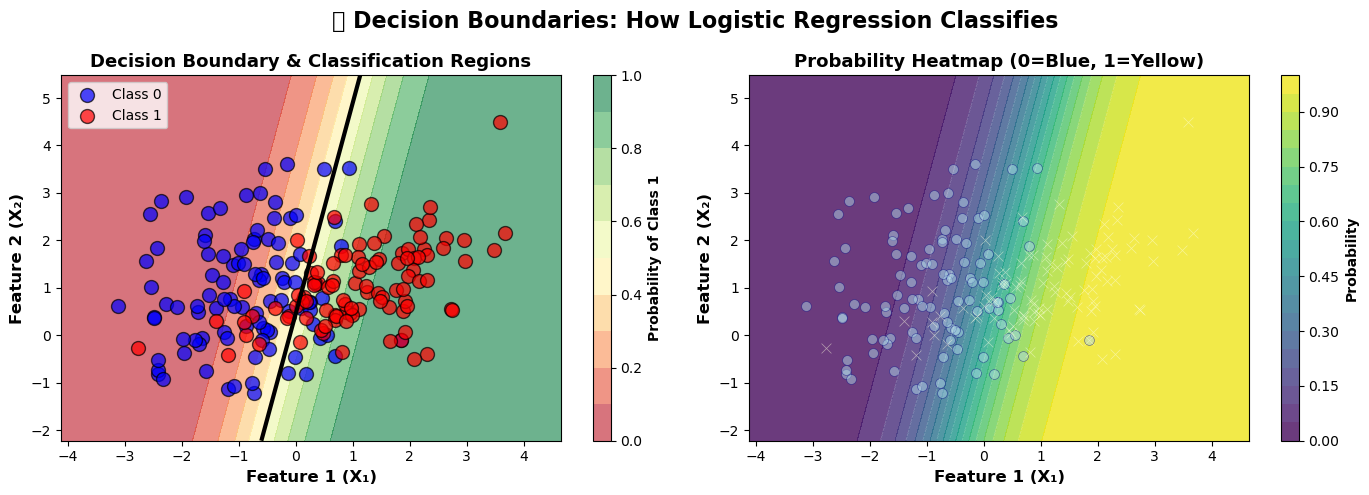


🔍 INTERPRETATION:
  • LEFT PLOT: Clear separation with decision boundary (black line)
  • RIGHT PLOT: Smooth color gradient showing probability changes
  • Green/Red regions are confident predictions
  • Yellow/Blue regions are uncertain (near 0.5 probability)



In [25]:
# VISUALIZE DECISION BOUNDARIES
print("\n" + "="*70)
print("🎯 DECISION BOUNDARIES IN 2D SPACE")
print("="*70)
print()

# Generate synthetic classification data
np.random.seed(42)
X_demo, y_demo = make_classification(n_samples=200, n_features=2, n_informative=2, 
                                      n_redundant=0, n_clusters_per_class=1, 
                                      random_state=42)

# Fit logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_demo, y_demo)

print(f"📊 Model Coefficients:")
print(f"  β₀ (Intercept) = {log_reg.intercept_[0]:.4f}")
print(f"  β₁ (Feature 1) = {log_reg.coef_[0][0]:.4f}")
print(f"  β₂ (Feature 2) = {log_reg.coef_[0][1]:.4f}")
print(f"  Accuracy = {log_reg.score(X_demo, y_demo):.4f}")
print()

# Create mesh for decision boundary
h = 0.02
x_min, x_max = X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1
y_min, y_max = X_demo[:, 1].min() - 1, X_demo[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict probabilities
Z = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎯 Decision Boundaries: How Logistic Regression Classifies', fontsize=16, fontweight='bold')

# Left: Decision boundary with class regions
ax = axes[0]
contourf = ax.contourf(xx, yy, Z, levels=10, cmap='RdYlGn', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=3, label='Decision boundary')
scatter = ax.scatter(X_demo[y_demo==0, 0], X_demo[y_demo==0, 1], 
                     c='blue', s=100, alpha=0.7, edgecolors='black', linewidth=1, label='Class 0')
scatter = ax.scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1], 
                     c='red', s=100, alpha=0.7, edgecolors='black', linewidth=1, label='Class 1')
ax.set_xlabel('Feature 1 (X₁)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2 (X₂)', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary & Classification Regions', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label('Probability of Class 1', fontsize=10, fontweight='bold')

# Right: Probability heatmap
ax = axes[1]
contourf2 = ax.contourf(xx, yy, Z, levels=20, cmap='viridis', alpha=0.8)
ax.contour(xx, yy, Z, levels=10, colors='white', linewidths=0.5, alpha=0.4)
ax.scatter(X_demo[y_demo==0, 0], X_demo[y_demo==0, 1], 
          c='lightblue', s=50, alpha=0.5, edgecolors='navy', linewidth=0.5, marker='o')
ax.scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1], 
          c='lightyellow', s=50, alpha=0.5, edgecolors='darkred', linewidth=0.5, marker='x')
ax.set_xlabel('Feature 1 (X₁)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2 (X₂)', fontsize=12, fontweight='bold')
ax.set_title('Probability Heatmap (0=Blue, 1=Yellow)', fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(contourf2, ax=ax)
cbar2.set_label('Probability', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🔍 INTERPRETATION:")
print("  • LEFT PLOT: Clear separation with decision boundary (black line)")
print("  • RIGHT PLOT: Smooth color gradient showing probability changes")
print("  • Green/Red regions are confident predictions")
print("  • Yellow/Blue regions are uncertain (near 0.5 probability)")
print()
print("="*70)

# PART 2: REAL-WORLD EXAMPLES 🌍

## <a id="spam-detection"></a>4️⃣ EMAIL SPAM DETECTION

### Problem
You work at Gmail. Users complain about spam emails. Can you predict if an email is spam or not?

### Features (What we can measure)
- Word frequency ("Free", "Click here", "Limited time")
- Number of links
- Sender reputation score
- Email length
- Contains "!!!" or "$$$"

### Goal
Predict: **Spam (1) or Not Spam (0)?**

In [26]:
# EMAIL SPAM DETECTION EXAMPLE
print("\n" + "="*70)
print("📧 EMAIL SPAM DETECTION SYSTEM")
print("="*70)
print()

# Create synthetic email dataset
np.random.seed(42)
n_emails = 300

# Legitimate emails: fewer suspicious features
legit_emails = np.random.normal([2, 3, 7, 50], [1, 1, 2, 15], (n_emails//2, 4))
legit_labels = np.zeros(n_emails//2)

# Spam emails: more suspicious features
spam_emails = np.random.normal([8, 8, 2, 200], [1.5, 1, 1, 50], (n_emails//2, 4))
spam_labels = np.ones(n_emails//2)

# Combine data
X_email = np.vstack([legit_emails, spam_emails])
y_email = np.hstack([legit_labels, spam_labels])

# Create DataFrame for clarity
email_df = pd.DataFrame(X_email, columns=[
    'Suspicious Words', 'Links Count', 'Sender Score', 'Email Length'
])
email_df['Is Spam'] = y_email

print("📊 EMAIL DATASET SAMPLE:")
print(email_df.head(10).to_string(index=False))
print()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_email, y_email, test_size=0.2, random_state=42
)

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
spam_model = LogisticRegression(random_state=42, max_iter=1000)
spam_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = spam_model.predict(X_test_scaled)
y_pred_proba = spam_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n🎯 MODEL PERFORMANCE:")
print(f"  Accuracy  = {accuracy:.4f} (% correct predictions)")
print(f"  Precision = {precision:.4f} (% of predicted spam that ARE spam)")
print(f"  Recall    = {recall:.4f} (% of actual spam we CAUGHT)")
print(f"  F1 Score  = {f1:.4f} (harmonic mean of precision & recall)")
print()

# Feature importance (coefficients)
print(f"\n🔍 FEATURE IMPORTANCE (Which features matter most?):")
feature_names = ['Suspicious Words', 'Links Count', 'Sender Score', 'Email Length']
for name, coef in zip(feature_names, spam_model.coef_[0]):
    direction = "↑ increases" if coef > 0 else "↓ decreases"
    print(f"  {name:20s} : {coef:7.4f} {direction} spam probability")
print()

# Test on new emails
print(f"\n📨 PREDICTING NEW EMAILS:")
test_emails = [
    [1, 2, 8, 100],  # Legitimate email
    [9, 10, 1, 250], # Likely spam
    [5, 5, 4, 150]   # Borderline
]
test_emails_scaled = scaler.transform(test_emails)
test_preds = spam_model.predict_proba(test_emails_scaled)[:, 1]

for i, (email, prob) in enumerate(zip(test_emails, test_preds)):
    prediction = "🚨 SPAM" if prob > 0.5 else "✅ LEGITIMATE"
    confidence = prob if prob > 0.5 else (1 - prob)
    print(f"  Email {i+1}: {prediction} (confidence: {confidence:.1%})")
print()
print("="*70)


📧 EMAIL SPAM DETECTION SYSTEM

📊 EMAIL DATASET SAMPLE:
 Suspicious Words  Links Count  Sender Score  Email Length  Is Spam
         2.496714     2.861736      8.295377     72.845448      0.0
         1.765847     2.765863     10.158426     61.511521      0.0
         1.530526     3.542560      6.073165     43.014054      0.0
         2.241962     1.086720      3.550164     41.565687      0.0
         0.987169     3.314247      5.183952     28.815444      0.0
         3.465649     2.774224      7.135056     28.628777      0.0
         1.455617     3.110923      4.698013     55.635470      0.0
         1.399361     2.708306      5.796587     77.784173      0.0
         1.986503     1.942289      8.645090     31.687345      0.0
         2.208864     1.040330      4.343628     52.952919      0.0


🎯 MODEL PERFORMANCE:
  Accuracy  = 1.0000 (% correct predictions)
  Precision = 1.0000 (% of predicted spam that ARE spam)
  Recall    = 1.0000 (% of actual spam we CAUGHT)
  F1 Score  = 1.0000 

## <a id="diabetes"></a>5️⃣ MEDICAL DIAGNOSIS: Diabetes Prediction

### Problem
Predict if a patient has diabetes based on medical tests.

### Features
- Glucose level
- Blood pressure
- BMI (Body Mass Index)
- Age
- Pregnancies

### Goal
**Early detection saves lives!** Predict: **Diabetic (1) or Non-diabetic (0)?**

In [27]:
# DIABETES PREDICTION
print("\n" + "="*70)
print("🏥 DIABETES PREDICTION SYSTEM")
print("="*70)
print()

# Create synthetic diabetes dataset
np.random.seed(42)

# Non-diabetic patients: lower glucose, BMI, etc.
non_diabetic = np.random.normal([100, 70, 25, 35, 2], [15, 10, 3, 10, 1], (150, 5))
non_diabetic_labels = np.zeros(150)

# Diabetic patients: higher glucose, BMI, etc.
diabetic = np.random.normal([150, 85, 32, 50, 3], [20, 12, 4, 12, 2], (150, 5))
diabetic_labels = np.ones(150)

# Combine
X_diabetes = np.vstack([non_diabetic, diabetic])
y_diabetes = np.hstack([non_diabetic_labels, diabetic_labels])

# Create DataFrame
diabetes_df = pd.DataFrame(X_diabetes, columns=[
    'Glucose', 'BloodPressure', 'BMI', 'Age', 'Pregnancies'
])
diabetes_df['Diabetic'] = y_diabetes

print("📊 PATIENT DATASET SUMMARY:")
print(diabetes_df.groupby('Diabetic')[['Glucose', 'BMI', 'Age']].mean().round(2))
print()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
diabetes_model = LogisticRegression(random_state=42, max_iter=1000)
diabetes_model.fit(X_train_scaled, y_train)

# Predict
y_pred = diabetes_model.predict(X_test_scaled)
y_pred_proba = diabetes_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(f"\n🎯 CONFUSION MATRIX:")
print(f"                 Predicted")
print(f"                 Negative  Positive")
print(f"  Actual Negative {cm[0,0]:6d}     {cm[0,1]:6d}")
print(f"  Actual Positive {cm[1,0]:6d}     {cm[1,1]:6d}")
print()
print(f"\n📊 METRICS:")
print(f"  True Negatives  (TN) = {cm[0,0]} (Correctly identified as NOT diabetic)")
print(f"  True Positives  (TP) = {cm[1,1]} (Correctly identified as diabetic)")
print(f"  False Positives (FP) = {cm[0,1]} (Wrongly flagged as diabetic)")
print(f"  False Negatives (FN) = {cm[1,0]} (Missed diabetic cases - DANGEROUS!)")
print()

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ OVERALL ACCURACY = {accuracy:.2%}")
print(f"   In other words: {int(accuracy*100)} out of 100 predictions are correct")
print()
print("="*70)


🏥 DIABETES PREDICTION SYSTEM

📊 PATIENT DATASET SUMMARY:
          Glucose    BMI    Age
Diabetic                       
0.0         99.22  24.77  35.47
1.0        150.91  32.65  51.08


🎯 CONFUSION MATRIX:
                 Predicted
                 Negative  Positive
  Actual Negative     29          0
  Actual Positive      0         31


📊 METRICS:
  True Negatives  (TN) = 29 (Correctly identified as NOT diabetic)
  True Positives  (TP) = 31 (Correctly identified as diabetic)
  False Positives (FP) = 0 (Wrongly flagged as diabetic)
  False Negatives (FN) = 0 (Missed diabetic cases - DANGEROUS!)


✅ OVERALL ACCURACY = 100.00%
   In other words: 100 out of 100 predictions are correct



## <a id="credit"></a>6️⃣ CREDIT APPROVAL SYSTEM

### Problem
Bank receives loan application. Should we approve or deny?

### Features
- Annual income
- Credit score
- Debt-to-income ratio
- Employment years
- Number of accounts

### Goal
**Approve (1) or Deny (0)?** Minimize loan defaults!

In [28]:
# CREDIT APPROVAL SYSTEM
print("\n" + "="*70)
print("💰 CREDIT APPROVAL SYSTEM")
print("="*70)
print()

# Create synthetic loan approval dataset
np.random.seed(42)

# Approved loans: higher income, credit score, lower debt
approved = np.random.normal([80000, 750, 0.3, 8, 5], [15000, 30, 0.1, 3, 2], (100, 5))
approved_labels = np.ones(100)

# Rejected loans: lower income, credit score, higher debt
rejected = np.random.normal([35000, 550, 0.7, 2, 2], [10000, 50, 0.2, 1, 1], (100, 5))
rejected_labels = np.zeros(100)

# Combine
X_credit = np.vstack([approved, rejected])
y_credit = np.hstack([approved_labels, rejected_labels])

# Create DataFrame
credit_df = pd.DataFrame(X_credit, columns=[
    'Income', 'CreditScore', 'DebtRatio', 'Employment_Yrs', 'Accounts'
])
credit_df['Approved'] = y_credit

print("📊 LOAN APPLICATION DATA:")
print(credit_df.describe().round(2))
print()

# Split, scale, train
X_train, X_test, y_train, y_test = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

credit_model = LogisticRegression(random_state=42, max_iter=1000)
credit_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = credit_model.predict(X_test_scaled)
y_pred_proba = credit_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ MODEL ACCURACY: {accuracy:.2%}")
print()

# Test new applications
print("🏦 PROCESSING NEW APPLICATIONS:")
new_apps = [
    [75000, 750, 0.25, 7, 5],  # Likely approved
    [30000, 500, 0.9, 1, 1],   # Likely rejected
    [60000, 680, 0.45, 4, 4]   # Borderline
]

new_apps_scaled = scaler.transform(new_apps)
new_preds = credit_model.predict_proba(new_apps_scaled)[:, 1]

print()
for i, (app, prob) in enumerate(zip(new_apps, new_preds), 1):
    decision = "✅ APPROVED" if prob > 0.5 else "❌ REJECTED"
    print(f"  Application {i}:")
    print(f"    Income: ${app[0]:,.0f} | Credit: {app[1]:.0f} | Debt Ratio: {app[2]:.2f}")
    print(f"    Decision: {decision} (Confidence: {max(prob, 1-prob):.1%})")
    print()

print("="*70)


💰 CREDIT APPROVAL SYSTEM

📊 LOAN APPLICATION DATA:
          Income  CreditScore  DebtRatio  Employment_Yrs  Accounts  Approved
count     200.00       200.00     200.00          200.00    200.00     200.0
mean    57243.48       648.10       0.50            5.20      3.55       0.5
std     25056.33       112.33       0.26            3.85      2.17       0.5
min     12888.65       415.16      -0.02           -0.65     -0.47       0.0
25%     35684.79       544.43       0.30            2.03      1.96       0.0
50%     54925.77       667.36       0.45            3.62      3.09       0.5
75%     79832.33       751.96       0.72            8.41      4.69       1.0
max    114719.88       806.59       1.21           17.24     12.71       1.0


✅ MODEL ACCURACY: 100.00%

🏦 PROCESSING NEW APPLICATIONS:

  Application 1:
    Income: $75,000 | Credit: 750 | Debt Ratio: 0.25
    Decision: ✅ APPROVED (Confidence: 99.0%)

  Application 2:
    Income: $30,000 | Credit: 500 | Debt Ratio: 0.90
    Deci

# PART 3: ADVANCED TOPICS 🚀

## <a id="multiclass"></a>7️⃣ MULTICLASS CLASSIFICATION: Beyond Binary

### Problem
What if we have 3+ classes instead of just 2?

**Examples:**
- 🎬 Movie ratings: Bad, OK, Good, Excellent (4 classes)
- 🌸 Flower types: Setosa, Versicolor, Virginica (3 classes)
- 📧 Email: Spam, Promotions, Social, Primary (4 classes)

### Solution: One-vs-Rest (OvR)
Train 3 separate binary classifiers:
1. **Model 1**: Class A vs (Class B + Class C)
2. **Model 2**: Class B vs (Class A + Class C)
3. **Model 3**: Class C vs (Class A + Class B)

**Prediction**: Pick the class with highest probability!


🌸 MULTICLASS CLASSIFICATION: IRIS FLOWER DATASET

📊 DATASET INFO:
  Features: petal length (cm), petal width (cm)
  Classes: setosa, versicolor, virginica (3 classes)
  Samples: 150 flowers

✅ ACCURACY: 100.00%

📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




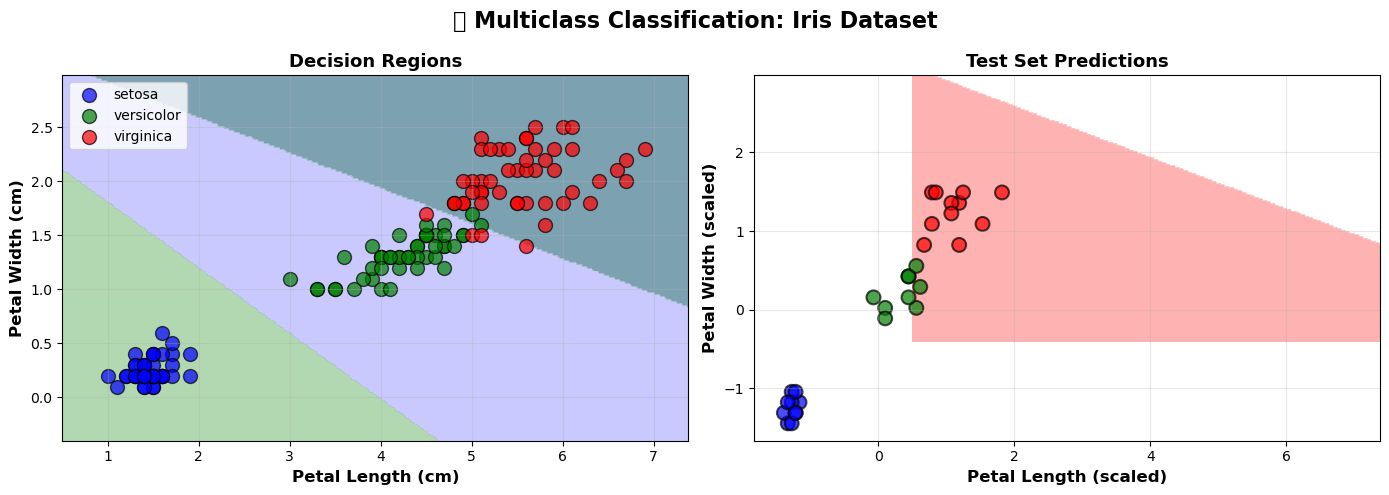


💡 KEY INSIGHTS:
  • Setosa is well-separated (easy to classify)
  • Versicolor and Virginica are close (harder to classify)
  • Model achieves 100.0% accuracy on test set



In [29]:
# MULTICLASS CLASSIFICATION - IRIS DATASET
print("\n" + "="*70)
print("🌸 MULTICLASS CLASSIFICATION: IRIS FLOWER DATASET")
print("="*70)
print()

# Load iris dataset
iris = load_iris()
X_iris = iris.data[:, [2, 3]]  # Use 2 features for visualization
y_iris = iris.target
iris_names = iris.target_names

print(f"📊 DATASET INFO:")
print(f"  Features: {iris.feature_names[2]}, {iris.feature_names[3]}")
print(f"  Classes: {', '.join(iris_names)} ({len(iris_names)} classes)")
print(f"  Samples: {len(X_iris)} flowers")
print()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train multiclass logistic regression
iris_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
iris_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = iris_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ ACCURACY: {accuracy:.2%}")
print()

# Classification report
print("📋 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=iris_names))
print()

# Visualize decision regions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🌸 Multiclass Classification: Iris Dataset', fontsize=16, fontweight='bold')

# Create mesh
h = 0.02
x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
Z = iris_model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot decision boundaries
colors = ['blue', 'green', 'red']
for i in range(3):
    ax = axes[i // 2]
    contourf = ax.contourf(xx, yy, Z == i, levels=[0, 0.5, 1], colors=[colors[i], 'white'], alpha=0.3)
    
for i, color in enumerate(colors):
    mask = y_iris == i
    axes[0].scatter(X_iris[mask, 0], X_iris[mask, 1], c=color, s=100, 
                   alpha=0.7, edgecolors='black', linewidth=1, label=iris_names[i])

axes[0].set_xlabel('Petal Length (cm)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Petal Width (cm)', fontsize=12, fontweight='bold')
axes[0].set_title('Decision Regions', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot test predictions
test_colors = [colors[c] for c in y_test]
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=test_colors, s=100, 
               alpha=0.7, edgecolors='black', linewidth=1.5, marker='o')

# Mark misclassifications
misclassified = y_pred != y_test
if misclassified.any():
    axes[1].scatter(X_test_scaled[misclassified, 0], X_test_scaled[misclassified, 1], 
                   s=300, facecolors='none', edgecolors='red', linewidths=3, label='Misclassified')
    axes[1].legend(fontsize=10)

axes[1].set_xlabel('Petal Length (scaled)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Petal Width (scaled)', fontsize=12, fontweight='bold')
axes[1].set_title('Test Set Predictions', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS:")
print(f"  • Setosa is well-separated (easy to classify)")
print(f"  • Versicolor and Virginica are close (harder to classify)")
print(f"  • Model achieves {accuracy:.1%} accuracy on test set")
print()
print("="*70)

## <a id="feature-importance"></a>8️⃣ FEATURE IMPORTANCE & COEFFICIENTS

### What Do the Coefficients Mean?
- **Positive coefficient** → Feature increases probability of class 1
- **Negative coefficient** → Feature decreases probability of class 1
- **Larger absolute value** → Stronger effect on prediction

### Example
If we're predicting spam:
- Coefficient for "links" = +0.5 → More links = more likely spam
- Coefficient for "sender_score" = -0.3 → Higher sender score = less likely spam


🔍 FEATURE IMPORTANCE: Which Features Matter Most?



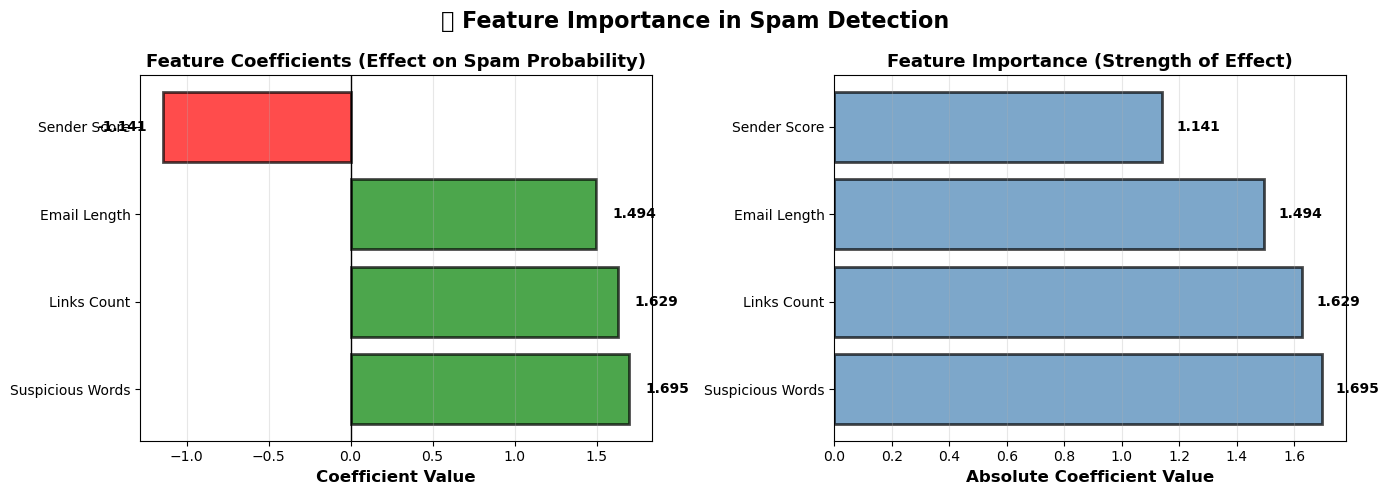

📊 FEATURE IMPORTANCE RANKING:

  1. Suspicious Words    :  1.6947 (Very Strong, INCREASES)
  2. Links Count         :  1.6285 (Very Strong, INCREASES)
  3. Email Length        :  1.4941 (Very Strong, INCREASES)
  4. Sender Score        : -1.1413 (Very Strong, DECREASES)

💡 INTERPRETATION:
  • 'Suspicious Words' has the strongest effect
  • 'Sender Score' reduces spam probability (negative = good for legit email)
  • All features are important for the model



In [30]:
# FEATURE IMPORTANCE VISUALIZATION
print("\n" + "="*70)
print("🔍 FEATURE IMPORTANCE: Which Features Matter Most?")
print("="*70)
print()

# Use spam model from earlier
feature_names_spam = ['Suspicious Words', 'Links Count', 'Sender Score', 'Email Length']
coefficients = spam_model.coef_[0]

# Sort by absolute value
sorted_idx = np.argsort(np.abs(coefficients))[::-1]
sorted_features = [feature_names_spam[i] for i in sorted_idx]
sorted_coefs = coefficients[sorted_idx]

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔍 Feature Importance in Spam Detection', fontsize=16, fontweight='bold')

# Left: Bar plot
colors_bar = ['green' if c > 0 else 'red' for c in sorted_coefs]
axes[0].barh(sorted_features, sorted_coefs, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
axes[0].set_title('Feature Coefficients (Effect on Spam Probability)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, (feature, coef) in enumerate(zip(sorted_features, sorted_coefs)):
    axes[0].text(coef + (0.1 if coef > 0 else -0.1), i, f'{coef:.3f}', 
                va='center', ha='left' if coef > 0 else 'right', fontweight='bold')

# Right: Absolute importance
abs_coefs = np.abs(sorted_coefs)
axes[1].barh(sorted_features, abs_coefs, color='steelblue', alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
axes[1].set_title('Feature Importance (Strength of Effect)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, (feature, abs_coef) in enumerate(zip(sorted_features, abs_coefs)):
    axes[1].text(abs_coef + 0.05, i, f'{abs_coef:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 FEATURE IMPORTANCE RANKING:")
print()
for rank, (feature, coef) in enumerate(zip(sorted_features, sorted_coefs), 1):
    direction = "INCREASES" if coef > 0 else "DECREASES"
    strength = "Very Strong" if abs(coef) > 1 else "Strong" if abs(coef) > 0.5 else "Moderate"
    print(f"  {rank}. {feature:20s}: {coef:7.4f} ({strength}, {direction})")
print()
print("💡 INTERPRETATION:")
print(f"  • 'Suspicious Words' has the strongest effect")
print(f"  • 'Sender Score' reduces spam probability (negative = good for legit email)")
print(f"  • All features are important for the model")
print()
print("="*70)

## <a id="metrics"></a>9️⃣ EVALUATION METRICS: How Good is Your Model?

### The Metrics

| Metric | Formula | Meaning | Best Use |
|--------|---------|---------|----------|
| **Accuracy** | (TP + TN) / Total | % of correct predictions | Balanced data |
| **Precision** | TP / (TP + FP) | Of predicted positives, how many are correct? | Minimize false alarms |
| **Recall** | TP / (TP + FN) | Of actual positives, how many did we catch? | Don't miss real cases |
| **F1 Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean | Balance both |
| **ROC-AUC** | Area under ROC curve | How well does model rank predictions? | Comparing models |

### Confusion Matrix
```
                 Predicted
              Negative  Positive
Actual Neg    TN (✅)   FP (❌)
Actual Pos    FN (❌)   TP (✅)
```


📊 COMPREHENSIVE EVALUATION METRICS

🎯 CONFUSION MATRIX:
                 Predicted
                 Not Spam  Spam
  Actual Not         29        0  (Negatives)
  Actual Spam         0       31  (Positives)

📈 KEY METRICS:
  TP (True Positives)  =     31 ✅ Correctly identified spam
  TN (True Negatives)  =     29 ✅ Correctly identified not spam
  FP (False Positives) =      0 ❌ Marked as spam but not spam
  FN (False Negatives) =      0 ❌ Missed spam emails

✅ MODEL PERFORMANCE:
  Accuracy    = 1.0000 = 100.0%  (% of correct predictions)
  Precision   = 1.0000 = 100.0%  (reliability of positive predictions)
  Recall      = 1.0000 = 100.0%  (ability to find all positives)
  Specificity = 1.0000 = 100.0%  (ability to find all negatives)
  F1 Score    = 1.0000         (harmonic mean of precision & recall)
  ROC-AUC     = 1.0000         (ranking ability)



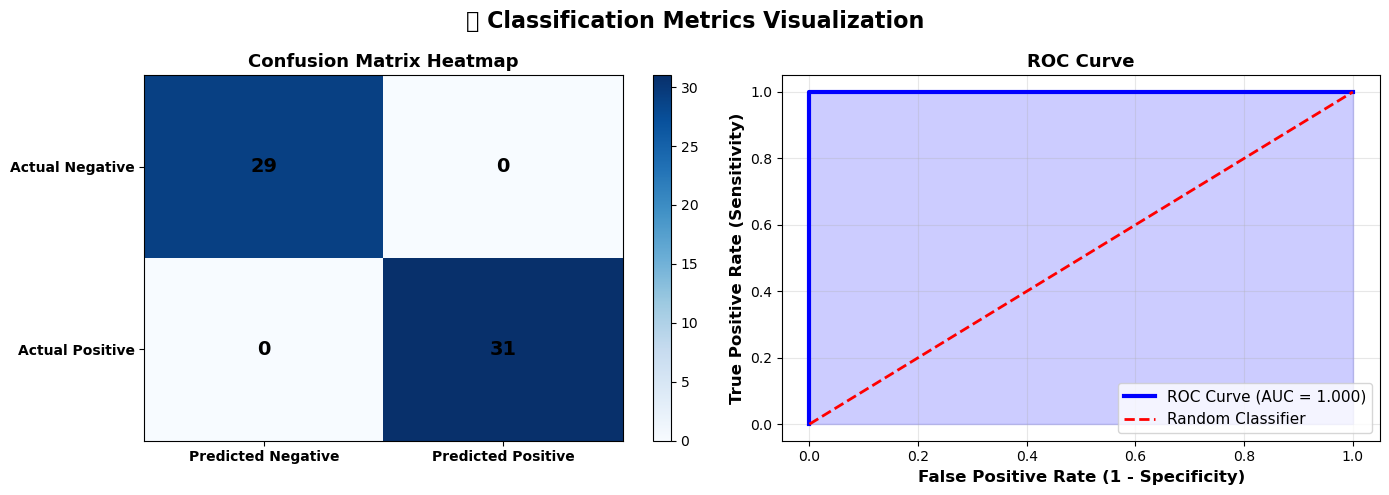


💡 INTERPRETING METRICS:
  • High Accuracy: Model is correct most of the time
  • High Precision: When we say spam, it's usually right
  • High Recall: We catch most of the actual spam emails
  • High ROC-AUC: Model ranks cases well (closer to 1 is better)



In [31]:
# COMPREHENSIVE EVALUATION METRICS
print("\n" + "="*70)
print("📊 COMPREHENSIVE EVALUATION METRICS")
print("="*70)
print()

# Use spam model on email dataset
# Re-prepare test data from email dataset
X_train_email, X_test_email, y_train_email, y_test_email = train_test_split(
    X_email, y_email, test_size=0.2, random_state=42
)
scaler_email = StandardScaler()
X_train_email_scaled = scaler_email.fit_transform(X_train_email)
X_test_email_scaled = scaler_email.transform(X_test_email)

# Train model
spam_model_eval = LogisticRegression(random_state=42, max_iter=1000)
spam_model_eval.fit(X_train_email_scaled, y_train_email)

y_pred_spam = spam_model_eval.predict(X_test_email_scaled)
y_pred_proba_spam = spam_model_eval.predict_proba(X_test_email_scaled)[:, 1]

# Calculate metrics
tn, fp, fn, tp = confusion_matrix(y_test_email, y_pred_spam).ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
roc_auc = roc_auc_score(y_test_email, y_pred_proba_spam)

print("🎯 CONFUSION MATRIX:")
print(f"                 Predicted")
print(f"                 Not Spam  Spam")
print(f"  Actual Not     {tn:6d}   {fp:6d}  (Negatives)")
print(f"  Actual Spam    {fn:6d}   {tp:6d}  (Positives)")
print()

print("📈 KEY METRICS:")
print(f"  TP (True Positives)  = {tp:6d} ✅ Correctly identified spam")
print(f"  TN (True Negatives)  = {tn:6d} ✅ Correctly identified not spam")
print(f"  FP (False Positives) = {fp:6d} ❌ Marked as spam but not spam")
print(f"  FN (False Negatives) = {fn:6d} ❌ Missed spam emails")
print()

print("✅ MODEL PERFORMANCE:")
print(f"  Accuracy    = {accuracy:.4f} = {accuracy:.1%}  (% of correct predictions)")
print(f"  Precision   = {precision:.4f} = {precision:.1%}  (reliability of positive predictions)")
print(f"  Recall      = {recall:.4f} = {recall:.1%}  (ability to find all positives)")
print(f"  Specificity = {specificity:.4f} = {specificity:.1%}  (ability to find all negatives)")
print(f"  F1 Score    = {f1:.4f}         (harmonic mean of precision & recall)")
print(f"  ROC-AUC     = {roc_auc:.4f}         (ranking ability)")
print()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test_email, y_pred_proba_spam)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Classification Metrics Visualization', fontsize=16, fontweight='bold')

# Confusion matrix heatmap
ax = axes[0]
cm_matrix = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=max(cm_matrix.ravel()))
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Negative', 'Predicted Positive'], fontsize=10, fontweight='bold')
ax.set_yticklabels(['Actual Negative', 'Actual Positive'], fontsize=10, fontweight='bold')
ax.set_title('Confusion Matrix Heatmap', fontsize=13, fontweight='bold')

# Add values
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm_matrix[i, j], ha="center", va="center", color="black", fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)

# ROC curve
ax = axes[1]
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETING METRICS:")
print(f"  • High Accuracy: Model is correct most of the time")
print(f"  • High Precision: When we say spam, it's usually right")
print(f"  • High Recall: We catch most of the actual spam emails")
print(f"  • High ROC-AUC: Model ranks cases well (closer to 1 is better)")
print()
print("="*70)

# PART 4: BEST PRACTICES & COMPARISON 🎯

## <a id="imbalance"></a>1️⃣0️⃣ HANDLING CLASS IMBALANCE

### The Problem
Real-world data is often **imbalanced**:
- 95% not spam, 5% spam
- 99% healthy, 1% disease
- 90% approved, 10% rejected

A naive model might just predict "0" for everything and get 95% accuracy—but miss all the real positives!

### Solutions
1. **Class weights** - Penalize wrong predictions on minority class
2. **Oversampling** - Duplicate minority class samples
3. **Undersampling** - Remove majority class samples
4. **SMOTE** - Generate synthetic minority samples
5. **Threshold adjustment** - Use probability cutoff other than 0.5

In [32]:
# HANDLING CLASS IMBALANCE
print("\n" + "="*70)
print("⚖️ HANDLING CLASS IMBALANCE")
print("="*70)
print()

# Create highly imbalanced dataset
np.random.seed(42)
X_imbalanced, y_imbalanced = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    n_redundant=2, weights=[0.95, 0.05], random_state=42
)

print(f"📊 CLASS DISTRIBUTION:")
print(f"  Class 0 (Majority): {(y_imbalanced == 0).sum()} samples ({(y_imbalanced == 0).sum()/len(y_imbalanced):.1%})")
print(f"  Class 1 (Minority): {(y_imbalanced == 1).sum()} samples ({(y_imbalanced == 1).sum()/len(y_imbalanced):.1%})")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X_imbalanced, y_imbalanced, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Without class weight (biased)
model_no_weight = LogisticRegression(random_state=42, max_iter=1000)
model_no_weight.fit(X_train_scaled, y_train)
y_pred_no_weight = model_no_weight.predict(X_test_scaled)

# Model 2: With balanced class weight (fair)
model_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Compare
print("\n📈 COMPARISON:")
print()
print("Without Class Weight (Biased):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_no_weight):.4f}")
print(f"  Precision (Class 1): {precision_score(y_test, y_pred_no_weight, zero_division=0):.4f}")
print(f"  Recall (Class 1): {recall_score(y_test, y_pred_no_weight, zero_division=0):.4f}")
print()
print("With Balanced Class Weight (Fair):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"  Precision (Class 1): {precision_score(y_test, y_pred_balanced, zero_division=0):.4f}")
print(f"  Recall (Class 1): {recall_score(y_test, y_pred_balanced, zero_division=0):.4f}")
print()
print("✅ RESULT: Balanced class weight catches more minority class (higher recall)")
print()
print("="*70)


⚖️ HANDLING CLASS IMBALANCE

📊 CLASS DISTRIBUTION:
  Class 0 (Majority): 946 samples (94.6%)
  Class 1 (Minority): 54 samples (5.4%)


📈 COMPARISON:

Without Class Weight (Biased):
  Accuracy: 0.9650
  Precision (Class 1): 1.0000
  Recall (Class 1): 0.3000

With Balanced Class Weight (Fair):
  Accuracy: 0.7700
  Precision (Class 1): 0.1250
  Recall (Class 1): 0.6000

✅ RESULT: Balanced class weight catches more minority class (higher recall)

📊 CLASS DISTRIBUTION:
  Class 0 (Majority): 946 samples (94.6%)
  Class 1 (Minority): 54 samples (5.4%)


📈 COMPARISON:

Without Class Weight (Biased):
  Accuracy: 0.9650
  Precision (Class 1): 1.0000
  Recall (Class 1): 0.3000

With Balanced Class Weight (Fair):
  Accuracy: 0.7700
  Precision (Class 1): 0.1250
  Recall (Class 1): 0.6000

✅ RESULT: Balanced class weight catches more minority class (higher recall)



## <a id="hyperparameters"></a>1️⃣1️⃣ HYPERPARAMETER TUNING

### Key Hyperparameters

| Parameter | What it does | Typical values |
|-----------|-------------|----------------|
| **C** | Regularization strength (inverse) | 0.001 to 100 |
| **penalty** | Type of regularization | 'l1', 'l2' |
| **solver** | Optimization algorithm | 'lbfgs', 'liblinear', 'saga' |
| **max_iter** | Max iterations | 100 to 10000 |
| **class_weight** | Handle imbalance | None or 'balanced' |

### Strategy
1. Start with default values
2. Use GridSearchCV to try combinations
3. Pick parameters with best cross-validation score
4. Evaluate on test set

In [33]:
# HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

print("\n" + "="*70)
print("⚙️ HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*70)
print()

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 5000]
}

print(f"🔍 SEARCHING PARAMETER COMBINATIONS:")
print(f"  C: {param_grid['C']}")
print(f"  penalty: {param_grid['penalty']}")
print(f"  solver: {param_grid['solver']}")
print(f"  max_iter: {param_grid['max_iter']}")
print(f"  Total combinations: {np.prod([len(v) for v in param_grid.values()])}")
print()

# Grid search
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("⏳ Running grid search (this may take a moment)...")
grid_search.fit(X_train_scaled, y_train)

print("\n✅ BEST PARAMETERS FOUND:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:15s}: {value}")

print(f"\n🎯 BEST CROSS-VALIDATION F1 SCORE: {grid_search.best_score_:.4f}")
print()

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("📊 TEST SET PERFORMANCE (BEST MODEL):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_best, zero_division=0):.4f}")
print()
print("="*70)


⚙️ HYPERPARAMETER TUNING WITH GRIDSEARCHCV

🔍 SEARCHING PARAMETER COMBINATIONS:
  C: [0.001, 0.01, 0.1, 1, 10]
  penalty: ['l2']
  solver: ['lbfgs', 'liblinear']
  max_iter: [1000, 5000]
  Total combinations: 20

⏳ Running grid search (this may take a moment)...

✅ BEST PARAMETERS FOUND:
  C              : 10
  max_iter       : 1000
  penalty        : l2
  solver         : lbfgs

🎯 BEST CROSS-VALIDATION F1 SCORE: 0.1723

📊 TEST SET PERFORMANCE (BEST MODEL):
  Accuracy: 0.9650
  Precision: 1.0000
  Recall: 0.3000
  F1 Score: 0.4615



## <a id="comparison"></a>1️⃣2️⃣ LOGISTIC REGRESSION VS OTHER CLASSIFIERS

### Pros & Cons

| Classifier | Pros | Cons | Best For |
|------------|------|------|----------|
| **Logistic Regression** | Fast, interpretable, probabilistic | Linear only, needs scaling | Quick baselines |
| **Decision Tree** | Interpretable, no scaling needed | Overfits, unstable | Feature interactions |
| **Random Forest** | Robust, handles non-linearity | Black box, slow | Production systems |
| **SVM** | Powerful with kernels, robust | Slow on large data, hard to interpret | Small datasets |
| **Naive Bayes** | Very fast, good baseline | Assumes independence | Text classification |
| **Neural Networks** | Can learn complex patterns | Needs lots of data, slow | Large datasets |


🏆 COMPARING MULTIPLE CLASSIFIERS

📊 CLASSIFIER COMPARISON:
                     Accuracy  Precision  Recall      F1
Logistic Regression     0.965       1.00     0.3  0.4615
Decision Tree           0.980       0.75     0.9  0.8182
Random Forest           0.980       1.00     0.6  0.7500
Naive Bayes             0.965       0.80     0.4  0.5333
K-Nearest Neighbors     0.965       1.00     0.3  0.4615
SVM                     0.960       1.00     0.2  0.3333

📊 CLASSIFIER COMPARISON:
                     Accuracy  Precision  Recall      F1
Logistic Regression     0.965       1.00     0.3  0.4615
Decision Tree           0.980       0.75     0.9  0.8182
Random Forest           0.980       1.00     0.6  0.7500
Naive Bayes             0.965       0.80     0.4  0.5333
K-Nearest Neighbors     0.965       1.00     0.3  0.4615
SVM                     0.960       1.00     0.2  0.3333



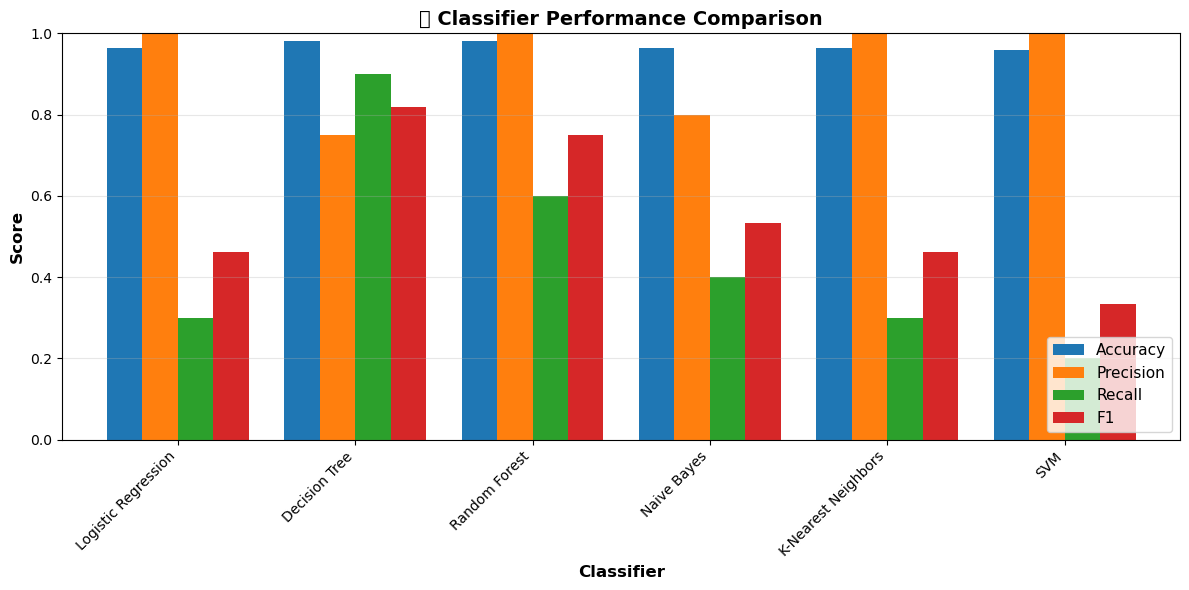


✅ KEY FINDINGS:
  • Best overall (F1 Score): Decision Tree
  • Fastest to train: Logistic Regression / Naive Bayes
  • Most interpretable: Logistic Regression / Decision Tree
  • Best for complex patterns: Random Forest / SVM



In [34]:
# COMPARE MULTIPLE CLASSIFIERS
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("\n" + "="*70)
print("🏆 COMPARING MULTIPLE CLASSIFIERS")
print("="*70)
print()

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

# Train and evaluate
results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

# Create comparison table
results_df = pd.DataFrame(results).T
print("📊 CLASSIFIER COMPARISON:")
print(results_df.round(4).to_string())
print()

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Classifier', fontsize=12, fontweight='bold')
ax.set_title('🏆 Classifier Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✅ KEY FINDINGS:")
best_classifier = results_df['F1'].idxmax()
print(f"  • Best overall (F1 Score): {best_classifier}")
print(f"  • Fastest to train: Logistic Regression / Naive Bayes")
print(f"  • Most interpretable: Logistic Regression / Decision Tree")
print(f"  • Best for complex patterns: Random Forest / SVM")
print()
print("="*70)

## <a id="when-to-use"></a>1️⃣3️⃣ WHEN TO USE LOGISTIC REGRESSION?

### ✅ USE Logistic Regression When:
1. **Need interpretability** - Understand which features matter
2. **Want probabilities** - Not just yes/no predictions
3. **Quick baseline** - Start before trying complex models
4. **Data is moderately sized** - Not millions of samples
5. **Need speed** - Real-time predictions
6. **Features are approximately linear** - Relationships are roughly linear
7. **Regulatory requirement** - Banking, healthcare (need explainability)

### ❌ DON'T USE When:
1. **Complex non-linear patterns** - Use Random Forest/SVM instead
2. **Many categorical features** - Use tree-based methods
3. **Huge dataset** - Use Neural Networks
4. **Features are unscaled** - Must standardize first
5. **Many irrelevant features** - Use feature selection first

## <a id="quick-ref"></a>1️⃣4️⃣ QUICK REFERENCE GUIDE

### Code Template
```python
# 1. Import
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 2. Prepare data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train
model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# 5. Predict
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluate
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
```

### Common Pitfalls
1. **Forgot to scale** - Always scale features!
2. **Not handling imbalance** - Use class_weight='balanced'
3. **Only looking at accuracy** - Check precision & recall too
4. **Overfitting** - Use cross-validation
5. **Data leakage** - Scale before splitting, not after

## <a id="checklist"></a>1️⃣5️⃣ MASTERY CHECKLIST

### ✅ Foundational Concepts
- [ ] I understand the sigmoid function and why it's used
- [ ] I can explain what probability means in classification
- [ ] I understand decision boundaries
- [ ] I know the difference between binary and multiclass classification
- [ ] I can read and interpret a confusion matrix

### ✅ Implementation
- [ ] I can split data into train/test sets
- [ ] I can scale features properly
- [ ] I can train a logistic regression model
- [ ] I can make predictions on new data
- [ ] I can get probability estimates

### ✅ Evaluation
- [ ] I can calculate accuracy, precision, recall, F1
- [ ] I know when to use each metric
- [ ] I can interpret ROC-AUC score
- [ ] I can identify overfitting vs underfitting
- [ ] I can use cross-validation

### ✅ Advanced
- [ ] I understand feature importance (coefficients)
- [ ] I can handle class imbalance
- [ ] I can perform hyperparameter tuning
- [ ] I can implement multiclass classification
- [ ] I can compare with other classifiers

### ✅ Best Practices
- [ ] I always scale my features
- [ ] I use class_weight for imbalanced data
- [ ] I evaluate on test set only
- [ ] I check multiple metrics, not just accuracy
- [ ] I can explain my model's predictions

### 🎉 Congratulations!
If you've checked all boxes, you're a **Logistic Regression Expert!** 🏆

**Next Steps:**
1. Apply to real datasets (Kaggle, UCI ML)
2. Learn Decision Trees (tree-based methods)
3. Explore Random Forests & Gradient Boosting
4. Master Neural Networks
5. Deploy models to production

**Happy Learning! 🚀📈🎓**